В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

import os

In [2]:
train_df = pd.read_csv("/content/train.csv")
train_tr_df, train_val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df['Exited'])

In [3]:
train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [4]:
train_tr_df.shape, train_val_df.shape

((11250, 14), (3750, 14))

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [5]:
target_col = 'Exited'
input_cols = [col for col in train_df.columns if col != target_col]

train_inputs = train_tr_df[input_cols]
train_targets = train_tr_df[target_col]

val_inputs = train_val_df[input_cols]
val_targets = train_val_df[target_col]

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [6]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11250 entries, 8263 to 1292
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11250 non-null  int64  
 1   CustomerId       11250 non-null  float64
 2   Surname          11250 non-null  object 
 3   CreditScore      11250 non-null  float64
 4   Geography        11250 non-null  object 
 5   Gender           11250 non-null  object 
 6   Age              11250 non-null  float64
 7   Tenure           11250 non-null  float64
 8   Balance          11250 non-null  float64
 9   NumOfProducts    11250 non-null  float64
 10  HasCrCard        11250 non-null  float64
 11  IsActiveMember   11250 non-null  float64
 12  EstimatedSalary  11250 non-null  float64
dtypes: float64(9), int64(1), object(3)
memory usage: 1.2+ MB


In [7]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [8]:
train_inputs[numeric_cols].describe().round(2)

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,7472.64,15691021.87,658.99,37.69,5.02,42952.89,1.59,0.79,0.49,117904.96
std,4328.35,150609.24,72.12,8.14,2.78,59923.39,0.53,0.41,0.50,45553.03
min,0.00,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,3734.25,15635241.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83155.87
50%,7447.50,15690134.00,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123587.94
75%,11208.75,15757396.25,709.00,42.00,7.00,109863.19,2.00,1.00,1.00,156774.94
max,14999.00,15815690.00,850.00,72.00,10.00,209767.31,4.00,1.00,1.00,199992.48


In [9]:
train_inputs[categorical_cols].nunique()

,0
Surname,720
Geography,3
Gender,2


Колонки `id`, `CustomerId` та `Surname` ніяк не впливають на те, покине кліент банк чи ні. Тому їх не потрібно враховувати у навчанні моделі.  
По іншим числовим колонкам - їх необхідно маштабувати, тому що наприклад `Age` від 18 до 72, а `Balance` від 0 до сотен тисяч.  
`Gender` має лише дві ознаки жінка та чоловік - тут підійде OneHotEncoder. `Geography` теж можна кодувати за допомогою OneHotEncoder.  
`HasCrCard` і `IsActiveMember` залишемо як є, тому що вони й так бінарні.  
Так як в датасеті немає пустих значень, то заповнювати їч чимось не потрібно.

In [54]:
cols_to_drop = ['id', 'CustomerId', 'Surname']
numeric_cols = [col for col in numeric_cols if col not in cols_to_drop]
categorical_cols = [col for col in categorical_cols if col not in cols_to_drop]

In [55]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [56]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [57]:
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols).tolist()
train_cat_encoded = encoder.transform(train_inputs[categorical_cols])
val_cat_encoded = encoder.transform(val_inputs[categorical_cols])

In [58]:
# StandardScaler
scaler_std = StandardScaler()
scaler_std.fit(train_inputs[numeric_cols])

StandardScaler()

In [59]:
train_num_std = scaler_std.transform(train_inputs[numeric_cols])
val_num_std = scaler_std.transform(val_inputs[numeric_cols])

In [60]:
all_features = numeric_cols + encoded_cat_cols
train_inputs_finish = pd.DataFrame(
    np.hstack([train_num_std, train_cat_encoded]),
    columns=all_features,
    index=train_inputs.index
)

val_inputs_finish = pd.DataFrame(
    np.hstack([val_num_std, val_cat_encoded]),
    columns=all_features,
    index=val_inputs.index
)

In [61]:
display(train_inputs_finish.head())
display(val_inputs_finish.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.513193,-0.698563,-0.008436,1.463179,-1.109137,0.512471,1.017939,-0.683158,1.0,0.0,0.0,0.0,1.0
14199,-0.374256,-0.698563,-0.367931,1.282909,-1.109137,0.512471,-0.982377,1.313519,0.0,1.0,0.0,1.0,0.0
1856,0.277465,-1.926640,-0.367931,-0.716829,0.771748,0.512471,1.017939,0.981199,1.0,0.0,0.0,1.0,0.0
3013,0.637991,1.266360,-0.727425,-0.716829,0.771748,0.512471,-0.982377,0.041916,1.0,0.0,0.0,0.0,1.0
8266,0.513193,-0.330140,0.710553,-0.716829,0.771748,0.512471,-0.982377,-0.383769,1.0,0.0,0.0,1.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,-1.608364,-1.066986,1.429542,1.280624,-1.109137,-1.951331,-0.982377,-1.363073,1.0,0.0,0.0,0.0,1.0
1273,-0.845713,0.406706,-0.727425,1.350297,-1.109137,0.512471,-0.982377,1.294460,0.0,1.0,0.0,0.0,1.0
5414,-0.526786,-0.821371,0.710553,-0.716829,-1.109137,0.512471,1.017939,0.709918,1.0,0.0,0.0,0.0,1.0
10923,-0.859579,2.248822,-0.727425,-0.716829,4.533520,0.512471,-0.982377,-0.328604,1.0,0.0,0.0,0.0,1.0
5835,1.248112,0.529514,-0.008436,-0.716829,-1.109137,0.512471,1.017939,1.402602,0.0,0.0,1.0,1.0,0.0


In [62]:
# MinMaxScaler
scaler_minmax = MinMaxScaler()
scaler_minmax.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [63]:
train_num_minmax = scaler_minmax.transform(train_inputs[numeric_cols])
val_num_minmax = scaler_minmax.transform(val_inputs[numeric_cols])

train_inputs_minmax = pd.DataFrame(
    np.hstack([train_num_minmax, train_cat_encoded]),
    columns=all_features,
    index=train_inputs.index
)

val_inputs_minmax = pd.DataFrame(
    np.hstack([val_num_minmax, val_cat_encoded]),
    columns=all_features,
    index=val_inputs.index
)

display(train_inputs_minmax.head())
display(val_inputs_minmax.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.632458,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1.0,0.0,0.0,0.0,1.0
14199,0.479714,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0.0,1.0,0.0,1.0,0.0
1856,0.591885,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,1.0,0.0,0.0,1.0,0.0
3013,0.653938,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1.0,0.0,0.0,0.0,1.0
8266,0.632458,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,1.0,0.0,0.0,1.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,0.267303,0.203704,0.9,0.570579,0.0,0.0,0.0,0.279047,1.0,0.0,0.0,0.0,1.0
1273,0.398568,0.425926,0.3,0.590481,0.0,1.0,0.0,0.884371,0.0,1.0,0.0,0.0,1.0
5414,0.453461,0.240741,0.7,0.000000,0.0,1.0,1.0,0.751226,1.0,0.0,0.0,0.0,1.0
10923,0.396181,0.703704,0.3,0.000000,1.0,1.0,0.0,0.514675,1.0,0.0,0.0,0.0,1.0
5835,0.758950,0.444444,0.5,0.000000,0.0,1.0,1.0,0.909003,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [64]:
train_inputs_finish.to_parquet('train_inputs_std.parquet')
val_inputs_finish.to_parquet('val_inputs_std.parquet')

train_inputs_minmax.to_parquet('train_inputs_minmax.parquet')
val_inputs_minmax.to_parquet('val_inputs_minmax.parquet')

pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

print("Усі файли збережено!\n")
print("Список файлів у робочій директорії:")
print(os.listdir('.'))

Усі файли збережено!

Список файлів у робочій директорії:
['.config', 'train_inputs_std.parquet', 'train.csv', 'log_reg.joblib', 'val_inputs_std.parquet', 'train_inputs_minmax.parquet', 'test.csv', 'val_targets.parquet', 'sample_submission.csv', 'train_targets.parquet', 'val_inputs_minmax.parquet', 'sample_data']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [65]:
# варіант зі StandardScaler)
X_train = train_inputs_finish
X_val = val_inputs_finish

y_train = train_targets
y_val = val_targets

In [66]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    f1_score,
    accuracy_score
)

In [68]:
train_probs = model.predict_proba(X_train)
val_probs = model.predict_proba(X_val)

train_preds = np.argmax(train_probs, axis=1)
val_preds = np.argmax(val_probs, axis=1)

train_probs_1 = train_probs[:, 1]
val_probs_1 = val_probs[:, 1]

In [69]:
print(f"Train F1-Score (поріг 0.5): {f1_score(y_train, train_preds):.4f}")
print(f"Val F1-Score (поріг 0.5):   {f1_score(y_val, val_preds):.4f}\n")

Train F1-Score (поріг 0.5): 0.6417
Val F1-Score (поріг 0.5):   0.6383



Метрика F1-Score більша за 0,5 що є хорошим результатом. Різниця між train F1 i val F1 дуже мала - зачить модель не перенавчена.

In [70]:
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, train_probs_1)
train_auc = auc(fpr_train, tpr_train)

fpr_val, tpr_val, thresholds_мфд = roc_curve(y_val, val_probs_1)
val_auc = auc(fpr_val, tpr_val)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Val AUROC:   {val_auc:.4f}\n")

Train AUROC: 0.8827
Val AUROC:   0.8799



AUROC: 0.88 - означає що у 88% випадків модель правильно відрізнить клієнта, який збирається піти, від клієнта, який планує залишитися

In [71]:
accuracy_score(train_targets, train_preds)

0.8748444444444444

In [72]:
confusion_matrix(train_targets, train_preds)

array([[8581,  380],
       [1028, 1261]])

In [73]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.48%
Accuracy: 87.09%


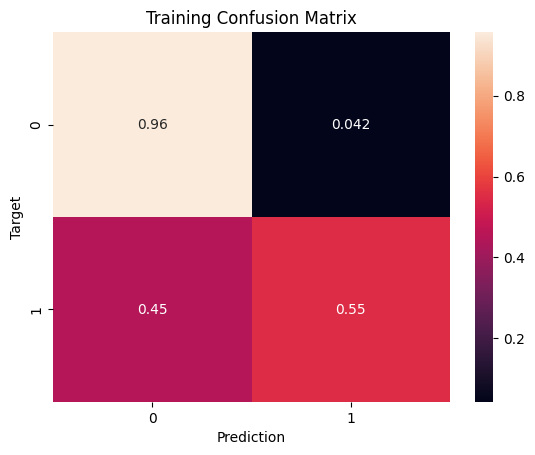

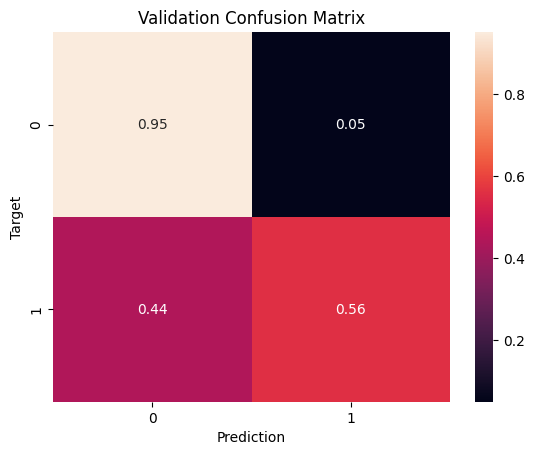

In [74]:
import seaborn as sns
train_preds = predict_and_plot(X_train, train_targets, 'Training')
val_preds = predict_and_plot(X_val, y_val, 'Validation')

Точність моделі на тестовому та валідаційному наборах майже 87%, що свідчить про те, що наша модель добре узагальнює дані, які вона раніше не бачила.

In [75]:
# ROC CURVE (ROC-КРИВА)
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

  # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


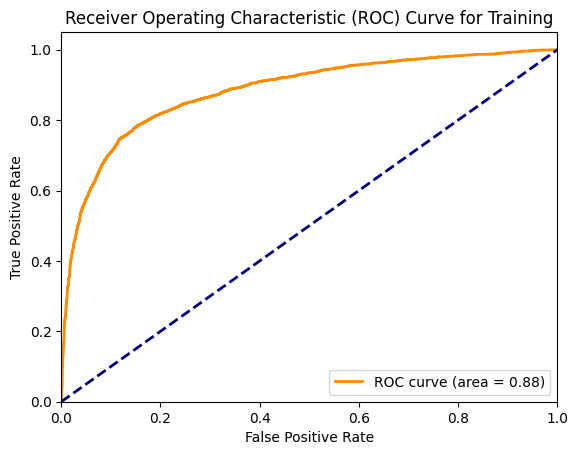

AUROC for Validation: 0.88


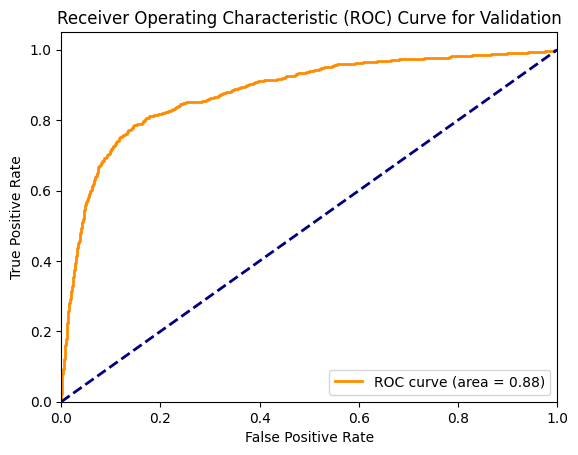

In [76]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

у 88% випадків модель правильно оцінить ймовірність відтоку вище для того клієнта, який збирається піти, ніж для того, який залишиться.

In [ ]:
# MinMaxScaler
model_minmax = LogisticRegression(solver='liblinear')
model_minmax.fit(train_inputs_minmax, y_train)

val_probs_minmax = model_minmax.predict_proba(val_inputs_minmax)[:, 1]
val_auc_minmax = roc_auc_score(y_val, val_probs_minmax)

print(f"ROC AUC на валідації з MinMaxScaler: {val_auc_minmax:.4f}")

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [77]:
train_targets.mode()[0]

np.float64(0.0)

In [78]:
majority_class = int(train_targets.mode()[0])

majority_train_preds = np.full(shape=len(train_targets), fill_value=majority_class)
majority_val_preds = np.full(shape=len(val_targets), fill_value=majority_class)

model_train_preds = model.predict(X_train)
model_val_preds = model.predict(X_val)

accuracy_majority_train = accuracy_score(train_targets, majority_train_preds)
accuracy_majority_val = accuracy_score(val_targets, majority_val_preds)

accuracy_model_train = accuracy_score(train_targets, model_train_preds)
accuracy_model_val = accuracy_score(val_targets, model_val_preds)

print("--- ПОРІВНЯННЯ ACCURACY ---")
print(f"Мажорітарна модель - всі значення {majority_class}")
print(f"Мажорітарна модель на Train: {accuracy_majority_train*100:.2f}%")
print(f"Мажорітарна модель на Val:   {accuracy_majority_val*100:.2f}%")
print("-" * 40)
print(f"Попередня модель на Train: {accuracy_model_train*100:.2f}%")
print(f"Попередня модель на Val:   {accuracy_model_val*100:.2f}%")

--- ПОРІВНЯННЯ ACCURACY ---
Мажорітарна модель - всі значення 0
Мажорітарна модель на Train: 79.65%
Мажорітарна модель на Val:   79.65%
----------------------------------------
Попередня модель на Train: 87.48%
Попередня модель на Val:   87.09%


Тобто якщо припустити що всі кліенти у банку залишаються, то верогідність такої моделі 79,65%. Всі моделі з верогідністю нижче за цей поріг - будут непридатні.  
Натренерована попередня можель має ACCURACY приблизно 87% і це означає що вона працює краще.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [79]:
import joblib
objects_to_save = {
    'model': model,
    'scaler': scaler_std,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cat_cols
}

In [80]:
joblib.dump(objects_to_save, 'log_reg.joblib')

['log_reg.joblib']

In [81]:
loaded_objects = joblib.load('log_reg.joblib')

model_2 = loaded_objects['model']

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [82]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(model, scaler, encoder, numeric_cols, categorical_cols, encoded_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [83]:
predict_raw_df(
    model = model_2,
    scaler = scaler_std,
    encoder = encoder,
    numeric_cols = numeric_cols,
    categorical_cols = categorical_cols,
    encoded_cols = encoded_cat_cols,
    input_df = train_df[:5]
)

array([0.00551959, 0.03362152, 0.37855144, 0.38051941, 0.97931306])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [84]:
test_raw_df = pd.read_csv("/content/test.csv")
test_raw_df['Exited'] = predict_raw_df(
    model = model_2,
    scaler = scaler_std,
    encoder = encoder,
    numeric_cols = numeric_cols,
    categorical_cols = categorical_cols,
    encoded_cols = encoded_cat_cols,
    input_df = test_raw_df
)

In [85]:
test_raw_df[:5]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
0,15000,15594796.0,Chu,-1.039842,Germany,Male,-0.944178,-1.086920,1.720620,-1.109137,0.512471,1.017939,0.877849,0.0,1.0,0.0,0.0,1.0,0.069080
1,15001,15642821.0,Mazzi,-1.497433,France,Male,0.161091,-0.008436,-0.716829,0.771748,0.512471,1.017939,-1.108070,1.0,0.0,0.0,0.0,1.0,0.032669
2,15002,15716284.0,Onyekachi,0.651857,France,Male,0.652322,1.070048,-0.716829,0.771748,0.512471,-0.982377,0.853186,1.0,0.0,0.0,0.0,1.0,0.151201
3,15003,15785078.0,Martin,0.804387,Spain,Male,0.897937,-0.727425,-0.716829,-1.109137,0.512471,1.017939,1.075825,0.0,0.0,1.0,0.0,1.0,0.201191
4,15004,15662955.0,Kenechukwu,-0.928911,Spain,Male,0.652322,1.070048,-0.716829,0.771748,0.512471,1.017939,0.565893,0.0,0.0,1.0,0.0,1.0,0.053823


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [86]:
sample = pd.read_csv("/content/sample_submission.csv")

In [88]:
sample['Exited'] = test_raw_df['Exited']

In [89]:
sample.head()

,id,Exited
0,15000,0.069080
1,15001,0.032669
2,15002,0.151201
3,15003,0.201191
4,15004,0.053823


In [90]:
sample.to_csv('submission_log_reg.csv', index=False)